# Projeto da Disciplina — Machine Learning Supervisionado

**Aluno:** Andrei  
**Dataset:** Adult Census Income (UCI Machine Learning Repository)

---  
## 1. Descrição do Problema e dos Dados

#### 1.1 Contexto e Motivação

O problema consiste em **prever se um indivíduo possui renda anual superior a USD 50.000**, com base em dados demográficos e socioeconômicos do Censo Americano de 1994. A aplicação prática é a **concessão de crédito**: a instituição precisa tomar uma decisão binária (aprovar/negar) sem acesso direto ao comprovante de renda.

Regras fixas são insuficientes porque a relação entre renda e as features disponíveis envolve **interações não lineares** (ex.: o efeito da escolaridade depende da ocupação e da carga horária). Machine learning supervisionado aprende esses padrões automaticamente a partir dos dados históricos rotulados.

#### 1.2. Desafios do Domínio

- **Desbalanceamento de classes**: a classe majoritária (≤ 50K) representa ~75% dos dados — F1-score, precision e recall serão priorizados sobre a acurácia.
- **Custo assimétrico de erros**: Falso Positivo (aprovar quem não tem renda suficiente) e Falso Negativo (negar quem tem) possuem custos distintos para o negócio.
- **Variáveis categóricas**: exigem encoding adequado (ordinal vs. nominal).
- **Ruído nos dados**: campos como `workclass` e `occupation` contêm entradas `?` representando respostas ausentes.

#### 1.3. Descrição Técnica do Dataset

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# carregar o dataset
df = pd.read_csv(r'data\train.csv')
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income_>50K
0,67,Private,366425,Doctorate,16,Divorced,Exec-managerial,Not-in-family,White,Male,99999,0,60,United-States,1
1,17,Private,244602,12th,8,Never-married,Other-service,Own-child,White,Male,0,0,15,United-States,0
2,31,Private,174201,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,1
3,58,State-gov,110199,7th-8th,4,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,0
4,25,State-gov,149248,Some-college,10,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,United-States,0


In [19]:
# visão geral
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43957 entries, 0 to 43956
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              43957 non-null  int64
 1   workclass        41459 non-null  str  
 2   fnlwgt           43957 non-null  int64
 3   education        43957 non-null  str  
 4   educational-num  43957 non-null  int64
 5   marital-status   43957 non-null  str  
 6   occupation       41451 non-null  str  
 7   relationship     43957 non-null  str  
 8   race             43957 non-null  str  
 9   gender           43957 non-null  str  
 10  capital-gain     43957 non-null  int64
 11  capital-loss     43957 non-null  int64
 12  hours-per-week   43957 non-null  int64
 13  native-country   43194 non-null  str  
 14  income_>50K      43957 non-null  int64
dtypes: int64(7), str(8)
memory usage: 5.0 MB


#### 1.4. Variável-Alvo

A variável `income_>50K` é **binária** (0 = renda ≤ 50K, 1 = renda > 50K). O problema é formulado como **classificação binária** porque o objetivo prático é uma decisão dicotômica, não a estimativa do valor exato da renda.

-- Contagem --
income_>50K
0    33439
1    10518
Name: count, dtype: int64

-- Proporção --
income_>50K
0    0.760721
1    0.239279
Name: proportion, dtype: float64


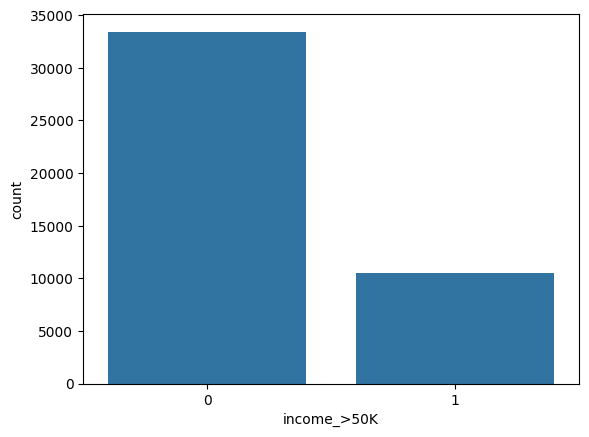

In [20]:
# distribuição da variável-alvo
print("-- Contagem --")
print(df['income_>50K'].value_counts())

print("\n-- Proporção --")
print(df['income_>50K'].value_counts(normalize=True))

sns.countplot(x='income_>50K', data=df)
plt.show()

#### 1.5 Remoção de Features

Três colunas serão descartadas antes da modelagem:

| Feature | Motivo |
|---|---|
| `fnlwgt` | Artefato amostral do Census Bureau, sem relação causal com a renda individual |
| `education` | Redundante com `educational-num` (mesma informação em formato numérico) |
| `native-country` | Alta cardinalidade (~40 países) com ~90% das observações em "United-States" |

#### 1.6 Features Utilizadas

**Variáveis Numéricas (5):**

| Feature | Descrição |
|---|---|
| `age` | Idade do indivíduo |
| `educational-num` | Anos de educação formal |
| `capital-gain` | Ganho de capital no ano fiscal |
| `capital-loss` | Perda de capital no ano fiscal |
| `hours-per-week` | Horas trabalhadas por semana |

**Variáveis Categóricas (6):**

| Feature | Tipo | Encoding previsto | Descrição
|---|---|---|---|
| `workclass` | Nominal | `OneHotEncoder` | Classe de trabalho _(privado, gov. est, gov, fed, autônomo etc)_ |
| `marital-status` | Nominal | `OneHotEncoder` | Situação matrimonial _(divorciado, nunca casou, cônjuge civil, cônjuge militar, separado, viúvo etc)_ |
| `occupation` | Nominal | `OneHotEncoder` | Profissão _(vendas, executivos, escritório, transportes, limpeza, agricultura, proteção, reparadores etc)_ |
| `relationship` | Nominal | `OneHotEncoder` | Relacionamento _(filho único, marido, esposa, sem familia etc)_ |
| `race` | Nominal | `OneHotEncoder` | Raça _(branco, negro, asiático)_ |
| `gender` | Nominal | `OneHotEncoder` | Gênero _(feminino, masculino)_ |

---
## 2. Pré-processamento dos dados
- Importação das bibliotecas
- Remoção de features indesejáveis
- Separação de dados - treino x teste
- Análise de outliers
- Análise de nulos
- Pipeline de pré-processamento

In [21]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')
RANDOM_STATE = 14

# Função para avaliar o desempenho do modelo - treino x teste
def evaluate_performance(y_true_train, y_pred_train, y_true_test, y_pred_test):
    print('Desempenho - Base de Treino')
    print(classification_report(y_true_train, y_pred_train))
    print('-' * 60)
    print('Desempenho - Base de Teste')
    print(classification_report(y_true_test, y_pred_test))

#### 2.1 Remover colunas indesejáveis

In [22]:
# carregar e remover colunas
df = pd.read_csv(r'data\train.csv')
df = df.drop(columns=['fnlwgt', 'education', 'native-country'])
df.shape

(43957, 12)

#### 2.2 Separação Teste x Treino

In [23]:
# separar x e y
x = df.drop(columns=['income_>50K'])
y = df['income_>50K']

# separar treino e teste com estratificação
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

# distribuição percentual
pd.DataFrame({
    'Original %': y.value_counts(normalize=True).sort_index() * 100,
    'Treino %': y_train.value_counts(normalize=True).sort_index() * 100,
    'Teste %': y_test.value_counts(normalize=True).sort_index() * 100
})

,Original %,Treino %,Teste %
income_>50K,,,
0,76.07207,76.073321,76.069154
1,23.92793,23.926679,23.930846


#### 2.3 Análise de outliers  
- `capital-gain` tem valor máximo muito discrepante, indica outlier

In [24]:
df.describe()

,age,educational-num,capital-gain,capital-loss,hours-per-week,income_>50K
count,43957.000000,43957.000000,43957.000000,43957.000000,43957.000000,43957.000000
mean,38.617149,10.074118,1093.559797,88.246491,40.407694,0.239279
std,13.734401,2.575092,7570.536063,404.588410,12.400303,0.426648
min,17.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000,1.000000


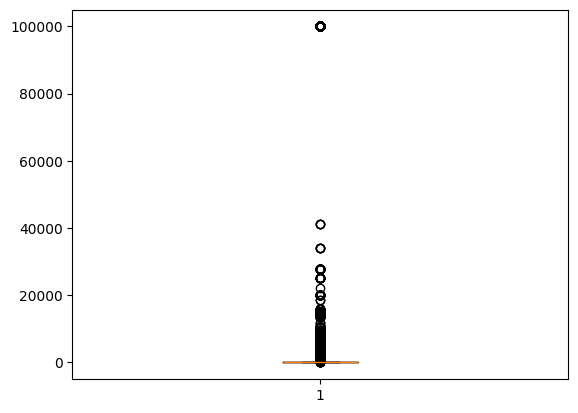

In [25]:
plt.boxplot(df['capital-gain'])
plt.show()

#### 2.4 Análise de nulos  
- duas variáveis categóricas possuem dados nulos `workclass` e `occupation`

In [26]:
pd.DataFrame({
    'Nulos (abs)': df.isnull().sum(),
    'Nulos (%)': (df.isnull().sum() / df.shape[0] * 100).round(2)
})

,Nulos (abs),Nulos (%)
age,0,0.00
workclass,2498,5.68
educational-num,0,0.00
marital-status,0,0.00
occupation,2506,5.70
relationship,0,0.00
race,0,0.00
gender,0,0.00
capital-gain,0,0.00
capital-loss,0,0.00


#### 2.5 Pipeline de pré-processamento  
- Essa pipeline de pré-processamento poderá ser usada em todos os modelos de treinamento do projeto (Perceptron, Decision Tree, SVM Linear)

In [27]:
# -- definir colunas por tipo --
cols_numeric = ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
cols_categorical = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender']

# -- definir transformers --
numeric_transformer = Pipeline(steps=[('scaler', RobustScaler())])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# RobustScaler: calcula a mediana e o IQR das features numéricas para tratar a escala, sendo resistente a outliers
# SimpleImputer: preenche com o valor mais frequente (moda) das features categóricas
# OneHotEncoder:  converte cada categoria em coluna binária

# -- associar transformers às colunas --
col_transformer = ColumnTransformer(transformers=[
    ('numeric', numeric_transformer, cols_numeric),
    ('categorical', categorical_transformer, cols_categorical)
])

# -- column transformer apenas para features categóricas - Decision Tree
col_transformer_dt = ColumnTransformer(transformers=[
    ('categorical', categorical_transformer, cols_categorical)
], remainder='passthrough')  # mantém colunas numéricas sem transformação

---
## 3. Modelo Baseline: Classificador Linear com Perceptron

O Perceptron é o modelo baseline do projeto: um classificador linear que aprende um hiperplano separador no espaço das features com base nos erros cometidos durante o treinamento (`y = β₀ + β₁x₁ + ... + βₙxₙ`). Sua simplicidade e interpretabilidade servem como referência mínima. Qualquer modelo mais complexo precisa superá-lo para se justificar.

O pré-processamento aplica `RobustScaler` nas variáveis numéricas (resistente a outliers, que são presentes em `capital-gain` e `capital-loss`) e `OneHotEncoder` nas categóricas. O `SimpleImputer` trata os valores `null` das colunas `workclass` e `occupation`.

#### 3.1. Treinamento Perceptron

In [28]:
# -- pipeline: pré-processamento + perceptron --
pipe_perceptron = Pipeline(steps=[
    ('col_transformer', col_transformer),
    ('perceptron', Perceptron(random_state=RANDOM_STATE))
])

# -- treinamento do Perceptron --
pipe_perceptron.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('col_transformer', ...), ('perceptron', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

#### 3.2. Previsões e desempenho do Perceptron

In [29]:
# previsões
yhat_train_perceptron = pipe_perceptron.predict(x_train) # modelo de treino
yhat_test_perceptron  = pipe_perceptron.predict(x_test) # modelo de teste

# desempenho do baseline
evaluate_performance(y_train, yhat_train_perceptron, y_test, yhat_test_perceptron)

Desempenho - Base de Treino
              precision    recall  f1-score   support

           0       0.87      0.87      0.87     23407
           1       0.58      0.58      0.58      7362

    accuracy                           0.80     30769
   macro avg       0.73      0.72      0.72     30769
weighted avg       0.80      0.80      0.80     30769

------------------------------------------------------------
Desempenho - Base de Teste
              precision    recall  f1-score   support

           0       0.86      0.87      0.87     10032
           1       0.57      0.56      0.57      3156

    accuracy                           0.80     13188
   macro avg       0.72      0.72      0.72     13188
weighted avg       0.79      0.80      0.79     13188



#### 3.3 Interpretação dos Coeficientes

Cada coeficiente β indica o impacto direto da feature sobre a decisão do modelo. Coeficientes positivos aumentam a probabilidade de classificação como `>50K`; negativos reduzem. O bias β₀ desloca o hiperplano independentemente das features, controlando o limiar de decisão.

In [30]:
# recuperar nomes das features após encoding
cat_features = pipe_perceptron.named_steps['col_transformer']\
    .named_transformers_['categorical']['encoder']\
    .get_feature_names_out(cols_categorical)

# cria lista completa de todas as features usadas no modelo
feature_names = cols_numeric + list(cat_features)

# coeficientes e bias
coefs = pd.Series(pipe_perceptron.named_steps['perceptron'].coef_[0], index=feature_names)
print(f'Bias (β₀): {pipe_perceptron.named_steps["perceptron"].intercept_[0]:.4f}')
print('\nTop 10 coeficientes por magnitude:')
coefs.abs().sort_values(ascending=False).head(10)

Bias (β₀): -717.0000

Top 10 coeficientes por magnitude:


capital-gain                         29664.0
relationship_Own-child                1604.0
capital-loss                          1442.0
marital-status_Never-married          1325.0
marital-status_Married-civ-spouse      574.0
relationship_Not-in-family             530.0
occupation_Other-service               222.0
relationship_Wife                      197.0
relationship_Other-relative            196.0
gender_Male                            179.0
dtype: float64

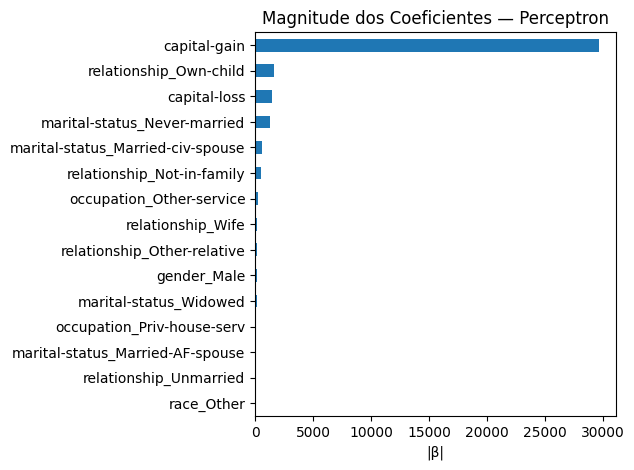

In [31]:
# visualização dos coeficientes mais relevantes
coefs.abs().sort_values(ascending=False).head(15).sort_values().plot(kind='barh')
plt.title('Magnitude dos Coeficientes — Perceptron')
plt.xlabel('|β|')
plt.tight_layout()
plt.show()

#### 3.4 Limitações do Perceptron

- **Não linearmente separável**: os dados de renda possuem interações complexas entre features (ex: efeito conjunto de `occupation` e `hours-per-week`) que um hiperplano único não consegue capturar. Isso se evidencia pelo baixo recall na classe `>50K`.
- **Sensibilidade a outliers**: mesmo com `RobustScaler`, o algoritmo de atualização de pesos por erro pode ser perturbado por registros atípicos em `capital-gain`.
- **Indícios de underfitting**: se as métricas de treino e teste forem igualmente baixas, o modelo não aprendeu os padrões, o que é esperado para um classificador linear neste domínio.

---
## 4. Modelo com Árvore de Decisão

A árvore de decisão é um modelo não-linear que aprende regras sequenciais do tipo if-then-else, criando fronteiras de decisão retangulares no espaço das features. Ao contrário do Perceptron, **não exige escalonamento** das variáveis numéricas, pois as divisões são baseadas em valores absolutos de corte. O pré-processamento mantém apenas o encoding das categóricas.

#### 4.1 Treinamento Decision Tree

In [32]:
# pipeline: pré-processamento + árvore com parâmetros padrão
pipe_dt = Pipeline(steps=[
    ('col_transformer', col_transformer_dt),
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

pipe_dt.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('col_transformer', ...), ('dt', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

#### 4.2 Previsões e desempenho do Decision Tree

In [33]:
# previsões
yhat_train_decision_tree = pipe_dt.predict(x_train)
yhat_test_decision_tree  = pipe_dt.predict(x_test)

# desempenho Decision Tree
evaluate_performance(y_train, yhat_train_decision_tree, y_test, yhat_test_decision_tree)


Desempenho - Base de Treino
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     23407
           1       0.98      0.91      0.95      7362

    accuracy                           0.97     30769
   macro avg       0.98      0.95      0.96     30769
weighted avg       0.97      0.97      0.97     30769

------------------------------------------------------------
Desempenho - Base de Teste
              precision    recall  f1-score   support

           0       0.88      0.89      0.88     10032
           1       0.63      0.60      0.62      3156

    accuracy                           0.82     13188
   macro avg       0.75      0.75      0.75     13188
weighted avg       0.82      0.82      0.82     13188



In [34]:
# estrutura da árvore
print(f'Profundidade: {pipe_dt.named_steps["dt"].get_depth()}')
print(f'Número de folhas: {pipe_dt.named_steps["dt"].get_n_leaves()}')

Profundidade: 47
Número de folhas: 5503


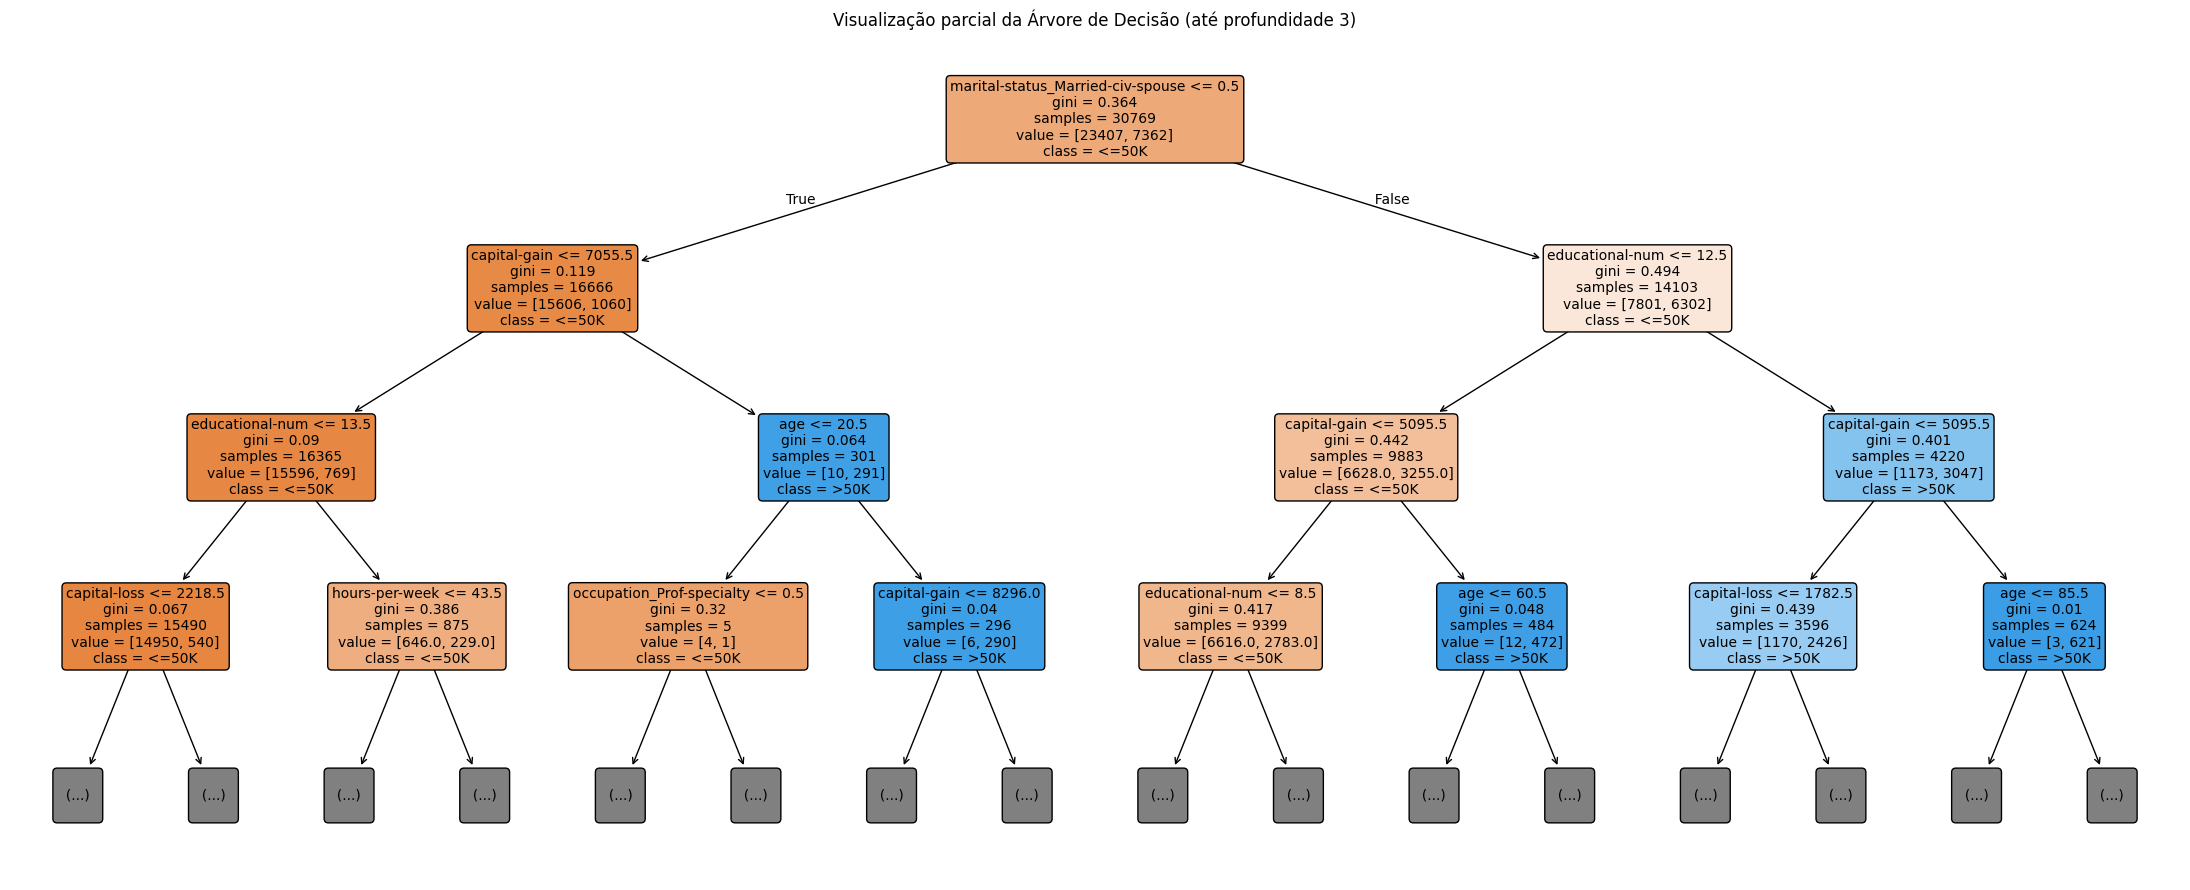

In [51]:
from sklearn.tree import plot_tree

# nomes das features no espaço transformado (OneHot + numéricas em passthrough)
cat_features_dt = pipe_dt.named_steps['col_transformer']\
    .named_transformers_['categorical']['encoder']\
    .get_feature_names_out(cols_categorical)

feature_names_dt = list(cat_features_dt) + cols_numeric

plt.figure(figsize=(22, 9))
plot_tree(
    pipe_dt.named_steps['dt'],
    feature_names=feature_names_dt,
    class_names=['<=50K', '>50K'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)
plt.title('Visualização parcial da Árvore de Decisão (até profundidade 3)')
plt.tight_layout()
plt.show()

#### 4.3 Interpretação e Risco de Overfitting

Uma árvore sem restrição de profundidade cresce até memorizar os dados de treino (accuracy 100% no treino), mas falha na generalização. O gap entre treino e teste nas métricas evidencia overfitting. As regras aprendidas podem ser verificadas via `feature_importances_`, que indicam quais features guiam as divisões no topo da árvore.

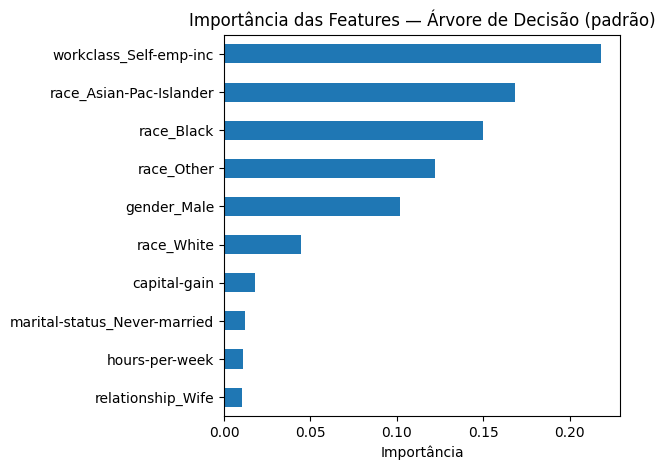

In [35]:
# importância das features
importances = pd.Series(
    pipe_dt.named_steps['dt'].feature_importances_,
    index=feature_names
)
importances.sort_values(ascending=False).head(10).sort_values().plot(kind='barh')
plt.title('Importância das Features — Árvore de Decisão (padrão)')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

#### 4.4. Comparação: Perceptron vs. Decision Tree

In [36]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Tabela comparativa simples
resultados = pd.DataFrame({
    'Modelo': ['Perceptron', 'Decision Tree'],
    'Accuracy (Teste)': [
        round(float(accuracy_score(y_test, yhat_test_perceptron)), 4),
        round(float(accuracy_score(y_test, yhat_test_decision_tree)), 4)
    ],
    'Precision (Teste)': [
        round(float(precision_score(y_test, yhat_test_perceptron, average='macro')), 4),
        round(float(precision_score(y_test, yhat_test_decision_tree, average='macro')), 4)
    ],
    'Recall (Teste)': [
        round(float(recall_score(y_test, yhat_test_perceptron, average='macro')), 4),
        round(float(recall_score(y_test, yhat_test_decision_tree, average='macro')), 4)
    ],
    'F1-Score (Teste)': [
        round(float(f1_score(y_test, yhat_test_perceptron, average='macro')), 4),
        round(float(f1_score(y_test, yhat_test_decision_tree, average='macro')), 4)
    ],
    'Gap Treino-Teste (F1)': [
        round(float(f1_score(y_train, yhat_train_perceptron, average='macro') - 
              f1_score(y_test, yhat_test_perceptron, average='macro')), 4),
        round(float(f1_score(y_train, yhat_train_decision_tree, average='macro') - 
              f1_score(y_test, yhat_test_decision_tree, average='macro')), 4)
    ]
})

resultados

,Modelo,Accuracy (Teste),Precision (Teste),Recall (Teste),F1-Score (Teste),Gap Treino-Teste (F1)
0,Perceptron,0.7950,0.7182,0.7162,0.7172,0.0078
1,Decision Tree,0.8192,0.7518,0.7455,0.7485,0.2158


**Interpretação:**

- A **Decision Tree** supera o **Perceptron** no conjunto de teste (F1: 0.75 vs 0.72), demonstrando capacidade de capturar relações não-lineares que o modelo linear não consegue.

- O **Perceptron** apresenta gap treino-teste muito baixo (~0.01), indicando **underfitting**: o modelo é simples demais para o problema.

- A **Decision Tree** apresenta gap elevado (~0.22), evidenciando **overfitting severo**: a árvore memorizou os dados de treino. Isso exige regularização via hiperparâmetros na próxima etapa.

---
## 5. Validação Cruzada e Busca de Hiperparâmetros

Para controlar o overfitting e encontrar a melhor configuração da árvore, utilizamos `RandomizedSearchCV` com `StratifiedKFold` (10 folds). O `StratifiedKFold` é essencial porque o dataset é desbalanceado, ele garante que a proporção de classes (~75/25) seja preservada em cada fold.

O `RandomizedSearchCV` é preferível ao `GridSearchCV` aqui pois o espaço de busca inclui `max_depth` com intervalo amplo, o que torna um cenário inadequado para testar todas combinações possíveis. Com `n_iter=100`, amostramos aleatoriamente 100 combinações, cobrindo bem o espaço sem custo excessivo.

A métrica de otimização escolhida é o **F1-score (macro)**, mais adequada que a acurácia em dados desbalanceados, ela equilibra precision e recall entre ambas as classes.

#### 5.1 Definir configurações para otimização

In [37]:
from scipy.stats import randint

# espaço de busca
param_dist = {
    'dt__criterion': ['gini', 'entropy'],
    'dt__max_depth': randint(2, 30),
    'dt__min_samples_leaf': randint(1, 50),
    'dt__class_weight': [None, 'balanced']
}

# validação cruzada estratificada
splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# busca aleatória
random_search = RandomizedSearchCV(
    estimator=pipe_dt,
    param_distributions=param_dist,
    n_iter=100,
    scoring='f1_macro',
    cv=splitter,
    refit=True,
    random_state=RANDOM_STATE,
    verbose=3,
    error_score=0
)

#### 5.2 Executar RandomizedSearchCV

In [38]:
# realizando os experimentos
random_search.fit(x_train, y_train)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
[CV 1/10] END dt__class_weight=balanced, dt__criterion=gini, dt__max_depth=14, dt__min_samples_leaf=23;, score=0.770 total time=   0.2s
[CV 2/10] END dt__class_weight=balanced, dt__criterion=gini, dt__max_depth=14, dt__min_samples_leaf=23;, score=0.773 total time=   0.2s
[CV 3/10] END dt__class_weight=balanced, dt__criterion=gini, dt__max_depth=14, dt__min_samples_leaf=23;, score=0.766 total time=   0.2s
[CV 4/10] END dt__class_weight=balanced, dt__criterion=gini, dt__max_depth=14, dt__min_samples_leaf=23;, score=0.758 total time=   0.4s
[CV 5/10] END dt__class_weight=balanced, dt__criterion=gini, dt__max_depth=14, dt__min_samples_leaf=23;, score=0.763 total time=   0.3s
[CV 6/10] END dt__class_weight=balanced, dt__criterion=gini, dt__max_depth=14, dt__min_samples_leaf=23;, score=0.775 total time=   0.2s
[CV 7/10] END dt__class_weight=balanced, dt__criterion=gini, dt__max_depth=14, dt__min_samples_leaf=23;, score=0.764 to

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=14))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'dt__class_weight': [None, 'balanced'], 'dt__criterion': ['gini', 'entropy'], 'dt__max_depth': <scipy.stats....002593217E6C0>, 'dt__min_samples_leaf': <scipy.stats....002590EA16A50>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the v

#### 5.3 Melhores hiperparâmetros

In [39]:
print('Melhores parâmetros:')
random_search.best_params_


Melhores parâmetros:


{'dt__class_weight': None,
 'dt__criterion': 'gini',
 'dt__max_depth': 18,
 'dt__min_samples_leaf': 41}

#### 5.4 Melhor desempenho médio

In [40]:
print('Melhor F1-macro médio (CV):')
round(float(random_search.best_score_), 4)

Melhor F1-macro médio (CV):


0.7936

#### 5.5 Análise de F1-macro em cada fold do melhor modelo

In [41]:
f1_cv = []
for i in range(10):
    score = random_search.cv_results_[f'split{i}_test_score'][
        np.where(random_search.cv_results_['rank_test_score'] == 1) # ← melhor modelo
    ][0]
    f1_cv.append(score)

print('F1-macro por fold:', [round(float(s), 4) for s in f1_cv])
print('Média:', round(float(np.mean(f1_cv)), 4))
print('Desvio padrão:', round(float(np.std(f1_cv)), 4))
print('CV (%):', round(float(np.std(f1_cv) * 100 / np.mean(f1_cv)), 2))

F1-macro por fold: [0.7996, 0.7794, 0.7893, 0.7978, 0.7886, 0.7983, 0.7803, 0.795, 0.8033, 0.8045]
Média: 0.7936
Desvio padrão: 0.0084
CV (%): 1.06


#### 5.6 Desempenho final do RandomizedSearchCV + StratifiedKFold

In [42]:
yhat_train_dt_random_search = random_search.best_estimator_.predict(x_train)  # type: ignore
yhat_test_dt_random_search  = random_search.best_estimator_.predict(x_test)  # type: ignore

evaluate_performance(y_train, yhat_train_dt_random_search, y_test, yhat_test_dt_random_search)

Desempenho - Base de Treino
              precision    recall  f1-score   support

           0       0.89      0.94      0.92     23407
           1       0.78      0.63      0.70      7362

    accuracy                           0.87     30769
   macro avg       0.84      0.79      0.81     30769
weighted avg       0.86      0.87      0.86     30769

------------------------------------------------------------
Desempenho - Base de Teste
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     10032
           1       0.75      0.60      0.66      3156

    accuracy                           0.86     13188
   macro avg       0.82      0.77      0.79     13188
weighted avg       0.85      0.86      0.85     13188



#### 5.7 Comparação: Árvore Padrão vs. Árvore Otimizada

In [43]:
dt_best = random_search.best_estimator_.named_steps['dt']  # type: ignore
comparacao_arvores = pd.DataFrame({
    'Modelo': ['Árvore (padrão)', 'Árvore (otimizada)'],
    'Accuracy (Teste)': [
        round(float(accuracy_score(y_test, yhat_test_decision_tree)), 4),
        round(float(accuracy_score(y_test, yhat_test_dt_random_search)), 4)
    ],
    'Precision (Teste)': [
        round(float(precision_score(y_test, yhat_test_decision_tree, average='macro')), 4),
        round(float(precision_score(y_test, yhat_test_dt_random_search, average='macro')), 4)
    ],
    'Recall (Teste)': [
        round(float(recall_score(y_test, yhat_test_decision_tree, average='macro')), 4),
        round(float(recall_score(y_test, yhat_test_dt_random_search, average='macro')), 4)
    ],
    'F1-Score (Teste)': [
        round(float(f1_score(y_test, yhat_test_decision_tree, average='macro')), 4),
        round(float(f1_score(y_test, yhat_test_dt_random_search, average='macro')), 4)
    ],
    'Gap Treino-Teste (F1)': [
        round(float(f1_score(y_train, yhat_train_decision_tree, average='macro') - 
              f1_score(y_test, yhat_test_decision_tree, average='macro')), 4),
        round(float(f1_score(y_train, yhat_train_dt_random_search, average='macro') - 
              f1_score(y_test, yhat_test_dt_random_search, average='macro')), 4)
    ],
    'Profundidade': [
        pipe_dt.named_steps['dt'].get_depth(),
        dt_best.get_depth()
    ],
    'Nº Folhas': [
        pipe_dt.named_steps['dt'].get_n_leaves(),
        dt_best.get_n_leaves()
    ]
})

comparacao_arvores

,Modelo,Accuracy (Teste),Precision (Teste),Recall (Teste),F1-Score (Teste),Gap Treino-Teste (F1),Profundidade,Nº Folhas
0,Árvore (padrão),0.8192,0.7518,0.7455,0.7485,0.2158,47,5503
1,Árvore (otimizada),0.8559,0.8156,0.7670,0.7864,0.0199,18,394


#### 5.8 Análise dos Resultados

O CV com 10 folds nos dá uma estimativa robusta da capacidade de generalização: a média e o desvio padrão do F1-macro revelam a estabilidade do modelo. Um coeficiente de variação baixo indica que o desempenho não depende do subconjunto de treino, ou seja, o modelo generaliza de forma consistente.

A regularização via `max_depth` e `min_samples_leaf` reduz a profundidade e o número de folhas em relação à árvore padrão, controlando o overfitting. O gap treino/teste diminui consideravelmente no modelo otimizado.

---
## 6. Modelo Avançado: SVM Linear

O `LinearSVC` implementa um SVM de margem máxima com kernel linear. Ao contrário do `SVC` com kernel não-linear, o `LinearSVC` escala bem para datasets grandes (~44k observações) com custo computacional muito inferior, sendo a escolha prática para este problema.

O escalonamento com `RobustScaler` é **obrigatório** para o SVM: o modelo é baseado em distâncias e a magnitude das features afeta diretamente a posição do hiperplano separador. Sem escalonamento, features com maior amplitude (como `capital-gain`) dominariam a otimização da margem.

O hiperparâmetro central é `C` (regularização): valores pequenos → maior regularização, margem mais larga, possível underfitting; valores grandes → menor regularização, ajuste mais fino aos dados, possível overfitting.

#### 6.1 Definir configurações para otimização

In [44]:
from scipy.stats import uniform

# pipeline: pré-processamento + LinearSVC
pipe_svm = Pipeline([
    ('col_transformer', col_transformer),
    ('svm', LinearSVC(random_state=RANDOM_STATE, max_iter=5000))
])

# espaço de busca
param_dist_svm = {
    'svm__C': uniform(0.01, 10),
    'svm__class_weight': [None, 'balanced']
}

# busca aleatória
random_search_svm = RandomizedSearchCV(
    estimator=pipe_svm,
    param_distributions=param_dist_svm,
    n_iter=30,
    scoring='f1_macro',
    cv=splitter,
    refit=True,
    random_state=RANDOM_STATE,
    verbose=3,
    error_score=0
)

#### 6.2 Executar SVM Linear

In [45]:
# realizando os experimentos
random_search_svm.fit(x_train, y_train)

Fitting 10 folds for each of 30 candidates, totalling 300 fits
[CV 1/10] END svm__C=5.149433437726902, svm__class_weight=None;, score=0.788 total time=   0.5s
[CV 2/10] END svm__C=5.149433437726902, svm__class_weight=None;, score=0.755 total time=   0.7s
[CV 3/10] END svm__C=5.149433437726902, svm__class_weight=None;, score=0.777 total time=   0.5s
[CV 4/10] END svm__C=5.149433437726902, svm__class_weight=None;, score=0.781 total time=   0.5s
[CV 5/10] END svm__C=5.149433437726902, svm__class_weight=None;, score=0.770 total time=   0.5s
[CV 6/10] END svm__C=5.149433437726902, svm__class_weight=None;, score=0.788 total time=   0.5s
[CV 7/10] END svm__C=5.149433437726902, svm__class_weight=None;, score=0.774 total time=   0.5s
[CV 8/10] END svm__C=5.149433437726902, svm__class_weight=None;, score=0.774 total time=   0.6s
[CV 9/10] END svm__C=5.149433437726902, svm__class_weight=None;, score=0.780 total time=   0.5s
[CV 10/10] END svm__C=5.149433437726902, svm__class_weight=None;, score=0

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=14))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svm__C': <scipy.stats....0025935C8BAA0>, 'svm__class_weight': [None, 'balanced']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value

#### 6.3 Melhores parâmetros

In [46]:
print('Melhores parâmetros:')
random_search_svm.best_params_

Melhores parâmetros:


{'svm__C': np.float64(5.149433437726902), 'svm__class_weight': None}

#### 6.4 Melhor desempenho médio

In [47]:
print('Melhor F1-macro médio (CV):')
round(float(random_search_svm.best_score_), 4)

Melhor F1-macro médio (CV):


0.7772

#### 6.5 Desempenho final do SVM Linear

In [48]:
yhat_train = random_search_svm.best_estimator_.predict(x_train)  # type: ignore
yhat_test  = random_search_svm.best_estimator_.predict(x_test)  # type: ignore

print('Desempenho - Base de Treino')
print(classification_report(y_train, yhat_train))
print('Desempenho - Base de Teste')
print(classification_report(y_test, yhat_test))

Desempenho - Base de Treino
              precision    recall  f1-score   support

           0       0.87      0.94      0.90     23407
           1       0.74      0.57      0.65      7362

    accuracy                           0.85     30769
   macro avg       0.81      0.76      0.78     30769
weighted avg       0.84      0.85      0.84     30769

Desempenho - Base de Teste
              precision    recall  f1-score   support

           0       0.87      0.94      0.90     10032
           1       0.74      0.56      0.64      3156

    accuracy                           0.85     13188
   macro avg       0.81      0.75      0.77     13188
weighted avg       0.84      0.85      0.84     13188



---
## 7. Comparação Final entre Modelos

A tabela abaixo consolida o F1-macro no conjunto de teste de todos os modelos treinados.

#### 7.1 Tabela de comparação de modelos

In [49]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

modelos = {
    'Perceptron (baseline)': pipe_perceptron,
    'Árvore (padrão)':       pipe_dt,
    'Árvore (otimizada)':    random_search.best_estimator_,  # type: ignore
    'SVM Linear':            random_search_svm.best_estimator_  # type: ignore
}

resultados = []
for nome, modelo in modelos.items():
    yhat = modelo.predict(x_test)  # type: ignore
    resultados.append({
        'Modelo':    nome,
        'Accuracy':  round(float(accuracy_score(y_test, yhat)), 4),
        'Precision': round(float(precision_score(y_test, yhat, average='macro')), 4),
        'Recall':    round(float(recall_score(y_test, yhat, average='macro')), 4),
        'F1-macro':  round(float(f1_score(y_test, yhat, average='macro')), 4)
    })

pd.DataFrame(resultados).set_index('Modelo')

,Accuracy,Precision,Recall,F1-macro
Modelo,,,,
Perceptron (baseline),0.7950,0.7182,0.7162,0.7172
Árvore (padrão),0.8192,0.7518,0.7455,0.7485
Árvore (otimizada),0.8559,0.8156,0.7670,0.7864
SVM Linear,0.8473,0.8053,0.7484,0.7699


#### 7.1 Gráfico de comparação de modelos

<Figure size 1200x600 with 0 Axes>

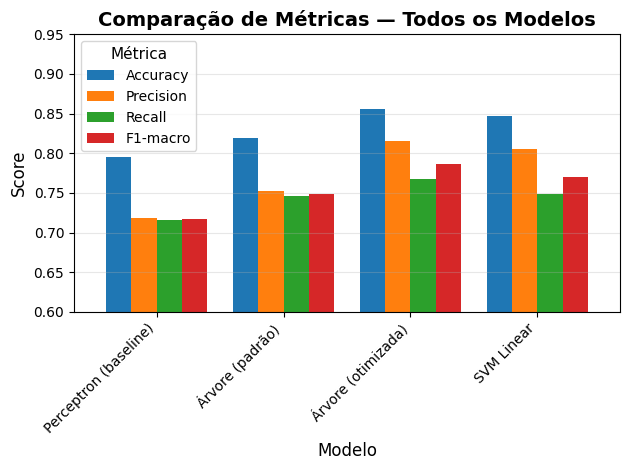

In [50]:
# Preparar dados para visualização
df_resultados = pd.DataFrame(resultados).set_index('Modelo')

# Criar gráfico de comparação de métricas
plt.figure(figsize=(12, 6))
df_resultados.plot(kind='bar', width=0.8)
plt.title('Comparação de Métricas — Todos os Modelos', fontsize=14, fontweight='bold')
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim([0.6, 0.95])
plt.legend(title='Métrica', fontsize=10, title_fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 7.2 Discussão

**Ganho de desempenho vs. complexidade:**

- O **Perceptron** serve como referência mínima. Seu baixo desempenho na classe `>50K` confirma a hipótese de underfitting: o problema não é linearmente separável.
- A **Árvore padrão** provavelmente supera o Perceptron em teste, porém com forte sinal de overfitting (treino >> teste), evidenciado pela profundidade irrestrita.
- A **Árvore otimizada** reduz o overfitting via regularização (`max_depth`, `min_samples_leaf`), com F1-macro mais estável entre treino e teste e desempenho superior ao baseline.
- O **SVM Linear** adiciona complexidade ao processo de busca e exige escalonamento obrigatório. Para dados que são parcialmente separáveis por hiperplano, pode equiparar ou superar levemente a árvore otimizada, com melhor generalização em alguns cenários, mas com custo computacional significativamente maior e perda de interpretabilidade das regras aprendidas.

**Limitações e possíveis melhorias:**

- O desbalanceamento (~75/25) afeta todos os modelos: `class_weight='balanced'` foi incluído no espaço de busca para mitigar isso.
- Possíveis extensões incluem engenharia de features (ex: cruzamento `occupation × education`), uso de `TargetEncoder` para reduzir dimensionalidade das categóricas, e modelos ensemble (Random Forest, XGBoost) como próximo passo.